# OAI Knee X-Ray Pipeline — Final Version
**Grade · Fix · Verify**  
Run every cell top-to-bottom in a fresh session.

| Check | Description |
|-------|-------------|
| **S1** | File inventory: PNG ↔ label match ≥ 98% |
| **S2** | Image integrity: 224×224, grayscale, brightness → **auto-resize fix** |
| **S3** | KL grade distribution (0-4), all grades present |
| **S4a** | DICOM tag audit: PA/AP view, photometric interpretation |
| **S4b** | KL asymmetry cross-check vs expert JSW measurements |
| **S4c** | **Crop orientation**: DICOM tags + fibula heuristic + visual spot-check → fix → verify |
| **S4d** | Label cross-validation vs official OAI grades + QWK kappa |
| **S4e** | R/L side balance by KL grade |
| **S4f** | Train/val/test split: create if missing → chi-squared verify |
| **S7** | Sample grids: 5 images per KL grade |
| **S8** | Final report: all verdicts + fix log |


## 0 — Setup

In [1]:
from google.colab import drive
drive.mount('/content/drive')
print('Drive mounted.')


Mounted at /content/drive
Drive mounted.


In [2]:
import sys, subprocess
subprocess.check_call([sys.executable, '-m', 'pip', 'install', '--quiet',
                       'pydicom', 'opencv-python-headless', 'scipy'])
print('Packages ready.')


Packages ready.


## 1 — Config, Paths & State

In [3]:
import os, random, shutil
from collections import Counter, defaultdict
from concurrent.futures import ThreadPoolExecutor, as_completed
from pathlib import Path

import cv2
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np
import pandas as pd
import pydicom
from PIL import Image
from scipy.stats import chi2_contingency

random.seed(42)
np.random.seed(42)

CFG = {
    'figure_dpi'          : 300,

    's1_match_thr'        : 0.98,

    's3_min_rows'         : 50,

    's4b_pass_pct'        : 80,
    's4b_unc_pct'         : 60,
    's4b_pass_ratio'      : 0.90,
    's4b_fail_ratio'      : 1.10,

    'orientation_override': 'PA',
    's4c_dicom_n'         : 100,

    's4d_w1_pass_pct'     : 85,
    's4d_w1_unc_pct'      : 70,

    's4e_fail_gap'        : 20,
    's4e_unc_gap'         : 10,

    'split_kl_pval'       : 0.05,
    'split_fracs'         : (0.70, 0.15, 0.15),
    'split_seed'          : 42,
}

PROJECT       = Path('/content/drive/MyDrive/Master Thesis')
OAI_DICOM_DIR = PROJECT / 'oai' / 'screening_images'
OAI_LABELS    = PROJECT / 'oai' / 'oai_labels.csv'
OAI_PROC_LBLS = PROJECT / 'oai' / 'oai_processed_labels.csv'
OAI_PNG_DIR   = PROJECT / 'oai' / 'processed'
ASSESS_DIR    = PROJECT / 'oai' / 'assessments'
OAI_JSW       = ASSESS_DIR / 'XR Knee Quant JSW'  / 'kxr_qjsw_duryea00.txt'
OAI_SQ        = ASSESS_DIR / 'XR Knee Semi-Quant' / 'KXR_SQ_BU00.txt'
OUT_DIR       = PROJECT / 'validation_report'
OUT_DIR.mkdir(parents=True, exist_ok=True)

verdicts    = {}
fix_log     = []
ORIENTATION = None

def _ok(p): return 'OK' if Path(p).exists() else 'MISSING'
def get_oai_labels():
    return OAI_PROC_LBLS if OAI_PROC_LBLS.exists() else OAI_LABELS

print('=== Path Status ===')
for name, p in [
    ('OAI DICOMs', OAI_DICOM_DIR), ('OAI Labels ', OAI_LABELS),
    ('OAI PNGs  ', OAI_PNG_DIR),   ('OAI JSW   ', OAI_JSW),
    ('OAI SQ    ', OAI_SQ),
]:
    print(f'  [{_ok(p)}]  {name}: {p}')


=== Path Status ===
  [OK]  OAI DICOMs: /content/drive/MyDrive/Master Thesis/oai/screening_images
  [OK]  OAI Labels : /content/drive/MyDrive/Master Thesis/oai/oai_labels.csv
  [OK]  OAI PNGs  : /content/drive/MyDrive/Master Thesis/oai/processed
  [OK]  OAI JSW   : /content/drive/MyDrive/Master Thesis/oai/assessments/XR Knee Quant JSW/kxr_qjsw_duryea00.txt
  [OK]  OAI SQ    : /content/drive/MyDrive/Master Thesis/oai/assessments/XR Knee Semi-Quant/KXR_SQ_BU00.txt


## 2 — Helper Functions

In [4]:

def log(msg):
    print(msg)
    fix_log.append(msg)

def atomic_save_csv(df, path):
    path = Path(path)
    tmp  = path.with_suffix('.tmp.csv')
    df.to_csv(tmp, index=False)
    tmp.replace(path)

def load_dicom_uint8(path):
    ds  = pydicom.dcmread(str(path))
    arr = ds.pixel_array.astype(np.float32)
    arr = (arr * float(getattr(ds, 'RescaleSlope',  1))
               + float(getattr(ds, 'RescaleIntercept', 0)))
    if getattr(ds, 'PhotometricInterpretation', 'MONOCHROME2') == 'MONOCHROME1':
        arr = arr.max() - arr
    lo, hi = float(np.percentile(arr, 1)), float(np.percentile(arr, 99))
    if hi - lo < 1:
        lo, hi = float(arr.min()), float(arr.max())
    return np.clip((arr - lo) / (hi - lo) * 255, 0, 255).astype(np.uint8)

def split_bilateral(arr):
    mid = arr.shape[1] // 2
    return arr[:, :mid], np.fliplr(arr[:, mid:])

_clahe_clip   = 2.0
_clahe_tile   = (8, 8)
_target_size  = 224
_clahe        = cv2.createCLAHE(clipLimit=_clahe_clip, tileGridSize=_clahe_tile)

def process_crop(crop_uint8, size=None):
    if size is None: size = _target_size
    img = Image.fromarray(crop_uint8).resize((size, size), Image.LANCZOS)
    arr = np.array(img)
    arr = _clahe.apply(arr)
    return arr

def normalise_side(series):
    s = series.astype(str).str.strip().str.upper()
    return s.replace({'RIGHT': 'R', 'LEFT': 'L', '1': 'R', '2': 'L'})

def detect_png_suffix(png_dir):
    for side in ('R', 'L'):
        probe = list(Path(png_dir).glob(f'OAI_*_{side}_*.png'))
        if probe:
            parts = probe[0].stem.split('_')
            for idx, p in enumerate(parts):
                if p == side and idx >= 2:
                    tail = '_'.join(parts[idx + 1:])
                    return f'_{tail}' if tail else ''
    return '_clahe-2.0_224px'

def parse_oai_stem(stem):
    parts = stem.split('_')
    if len(parts) >= 3 and parts[0] == 'OAI' and parts[2] in ('R', 'L'):
        return parts[1], parts[2]
    if len(parts) >= 2 and parts[-1] in ('R', 'L'):
        return '_'.join(parts[:-1]), parts[-1]
    return None, None

def fibula_side(crop):
    h, w  = crop.shape[:2]
    lower = crop[int(h * 0.55):, :]
    sx    = cv2.Sobel(lower.astype(np.float32), cv2.CV_32F, 1, 0, ksize=3)
    sy    = cv2.Sobel(lower.astype(np.float32), cv2.CV_32F, 0, 1, ksize=3)
    mag   = np.sqrt(sx**2 + sy**2)
    t     = w // 3
    l_sc  = float(mag[:, :t].mean())
    r_sc  = float(mag[:, -t:].mean())
    return ('LEFT' if l_sc > r_sc else 'RIGHT'), l_sc, r_sc

def quadratic_weighted_kappa(y_true, y_pred, n=5):
    y_true = np.asarray(y_true, int)
    y_pred = np.asarray(y_pred, int)
    if not len(y_true): return np.nan
    conf = np.zeros((n, n))
    for a, b in zip(y_true, y_pred):
        if 0 <= a < n and 0 <= b < n:
            conf[a, b] += 1
    tot = conf.sum()
    if not tot: return np.nan
    exp   = np.outer(conf.sum(1), conf.sum(0)) / tot
    w     = np.array([[(i-j)**2 / (n-1)**2 for j in range(n)] for i in range(n)])
    obs_w = (w * conf).sum() / tot
    exp_w = (w * exp ).sum() / tot
    return 1.0 - obs_w / (exp_w + 1e-12)

def stratified_subject_split(lbl_df, subject_col='subject_id',
                              kl_col='kl_grade', seed=42):
    tr_f, va_f, _ = CFG['split_fracs']
    rng = np.random.default_rng(seed)
    subj_kl = (lbl_df.groupby(subject_col)[kl_col]
               .apply(lambda x: int(pd.to_numeric(x, errors='coerce').max()))
               .reset_index().rename(columns={kl_col: 'max_kl'}))
    subj_kl['max_kl'] = subj_kl['max_kl'].clip(0, 4)
    split_map = {}
    for kl in range(5):
        stratum = subj_kl[subj_kl['max_kl'] == kl][subject_col].tolist()
        if not stratum: continue
        rng.shuffle(stratum)
        n    = len(stratum)
        n_tr = max(1, round(n * tr_f))
        rem  = n - n_tr
        n_va = (max(1, round(n * va_f)) if rem >= 2 else (1 if rem == 1 else 0))
        n_tr = min(n_tr, n - n_va)
        for s in stratum[:n_tr]:           split_map[s] = 'train'
        for s in stratum[n_tr:n_tr+n_va]:  split_map[s] = 'val'
        for s in stratum[n_tr+n_va:]:      split_map[s] = 'test'
    out = lbl_df.copy()
    out['split'] = out[subject_col].map(split_map).fillna('train')
    return out

PREFERRED_SERIES = '0.C.2'
subject_dicoms   = {}

if OAI_DICOM_DIR.exists():
    print('Scanning OAI DICOMs...')
    for _p in OAI_DICOM_DIR.rglob('*'):
        if _p.is_file() and _p.suffix == '':
            _pts = _p.relative_to(OAI_DICOM_DIR).parts
            if len(_pts) >= 2:
                subject_dicoms.setdefault(_pts[1], {})[_pts[0]] = _p
    print(f'  {len(subject_dicoms):,} subjects with DICOMs.')
else:
    print('OAI DICOM directory not found — DICOM checks will be SKIPPED.')

def best_dicom(sid):
    m = subject_dicoms.get(str(sid), {})
    return m.get(PREFERRED_SERIES) or (next(iter(m.values())) if m else None)

print('All helpers ready.')


Scanning OAI DICOMs...
  4,795 subjects with DICOMs.
All helpers ready.


---
## S1 — File Inventory: Check → Fix → Verify

In [5]:

def inventory_oai(png_dir, lbl_path):
    pngs      = list(Path(png_dir).glob('*.png')) if Path(png_dir).exists() else []
    png_stems = {p.stem for p in pngs}
    lbl_path  = Path(lbl_path)
    if not lbl_path.exists():
        return dict(PNGs=len(pngs), Labels='MISSING', Matched=0,
                    PNG_to_Lbl=0.0, Lbl_to_PNG=0.0,
                    Missing=0, Stray=len(pngs)), pngs, set(), png_stems
    df      = pd.read_csv(lbl_path)
    fc      = 'filename' if 'filename' in df.columns else df.columns[0]
    l_stems = {Path(x).stem for x in df[fc].astype(str)}
    matched = png_stems & l_stems
    return (dict(PNGs=len(pngs), Labels=len(df), Matched=len(matched),
                PNG_to_Lbl=round(100*len(matched)/max(len(png_stems),1), 2),
                Lbl_to_PNG=round(100*len(matched)/max(len(l_stems),  1), 2),
                Missing=len(l_stems - png_stems),
                Stray  =len(png_stems - l_stems)),
            pngs, l_stems - png_stems, png_stems - l_stems)

print('=== S1 CHECK ===')
_s1_row, _s1_pngs, _s1_missing, _s1_stray = inventory_oai(OAI_PNG_DIR, get_oai_labels())
thr = CFG['s1_match_thr'] * 100
s1_ok = _s1_row['PNG_to_Lbl'] >= thr and _s1_row['Lbl_to_PNG'] >= thr
print(f"  [{'PASS' if s1_ok else 'FAIL'}] OAI: {_s1_row['PNGs']:,} PNGs | "
      f"PNG->Lbl={_s1_row['PNG_to_Lbl']}%  Lbl->PNG={_s1_row['Lbl_to_PNG']}% | "
      f"missing={_s1_row['Missing']}  stray={_s1_row['Stray']}")


=== S1 CHECK ===
  [PASS] OAI: 8,547 PNGs | PNG->Lbl=100.0%  Lbl->PNG=100.0% | missing=0  stray=0


In [6]:

print('=== S1 FIX ===')

if _s1_stray:
    qdir = OAI_PNG_DIR.parent / (OAI_PNG_DIR.name + '_stray')
    qdir.mkdir(exist_ok=True)
    moved = 0
    for stem in _s1_stray:
        p = OAI_PNG_DIR / (stem + '.png')
        if p.exists():
            shutil.move(str(p), str(qdir / p.name))
            moved += 1
    log(f'S1 FIX: {moved} stray PNGs moved to {qdir.name}/ (recoverable)')
else:
    log('S1 FIX: no stray PNGs')

if _s1_missing:
    if not subject_dicoms:
        log(f'S1 FIX: {len(_s1_missing)} missing — DICOMs unavailable, manual repair needed')
    else:
        suffix   = detect_png_suffix(OAI_PNG_DIR)
        to_fix   = {}
        bad_stem = 0
        for stem in _s1_missing:
            sid, side = parse_oai_stem(stem)
            if sid: to_fix.setdefault(sid, set()).add(side)
            else:   bad_stem += 1
        if bad_stem:
            log(f'S1 FIX: {bad_stem} stems unparseable — skipped')
        ok_c = fail_c = nodicom_c = 0
        for sid, sides in to_fix.items():
            dcm = best_dicom(sid)
            if not dcm: nodicom_c += len(sides); continue
            try:
                full           = load_dicom_uint8(dcm)
                r_crop, l_crop = split_bilateral(full)
                for side, crop in (('R', r_crop), ('L', l_crop)):
                    if side in sides:
                        arr = process_crop(crop)
                        Image.fromarray(arr).save(
                            str(OAI_PNG_DIR / f'OAI_{sid}_{side}{suffix}.png'))
                        ok_c += 1
            except Exception as e:
                fail_c += len(sides)
        log(f'S1 FIX: repaired={ok_c}  no_dicom={nodicom_c}  errors={fail_c}')
else:
    log('S1 FIX: no missing PNGs')


=== S1 FIX ===
S1 FIX: no stray PNGs
S1 FIX: no missing PNGs


In [7]:

print('=== S1 VERIFY ===')
row, _, _, _ = inventory_oai(OAI_PNG_DIR, get_oai_labels())
thr          = CFG['s1_match_thr'] * 100
passed       = row['PNG_to_Lbl'] >= thr and row['Lbl_to_PNG'] >= thr
verdicts['S1'] = 'PASS' if passed else 'FAIL'
print(f"  [{'PASS' if passed else 'FAIL'}] OAI: "
      f"PNG->Lbl={row['PNG_to_Lbl']}%  Lbl->PNG={row['Lbl_to_PNG']}%")
pd.DataFrame([row]).to_csv(OUT_DIR / 's1_inventory.csv', index=False)
print(f'S1 verdict: {verdicts["S1"]}')


=== S1 VERIFY ===
  [PASS] OAI: PNG->Lbl=100.0%  Lbl->PNG=100.0%
S1 verdict: PASS


---
## S2 — Image Integrity: Check → Fix → Verify

Every image must be 224×224, grayscale, and have sensible brightness.
**Auto-fix**: wrong-size images are resized to 224×224 with CLAHE applied.
This corrects images regenerated from DICOMs that missed the resize step.


In [8]:

def check_integrity(png_dir):
    pngs = list(Path(png_dir).glob('*.png')) if Path(png_dir).exists() else []
    if not pngs:
        return {'Checked': 0, 'WrongSize': 0, 'WrongMode': 0,
                'Blank': 0, 'Dark': 0, 'Bright': 0, 'Verdict': 'SKIPPED'}, []
    wrong_size_paths = []
    wrong_mode = blank = dark = bright = 0
    means = []
    for p in pngs:
        try:
            img = Image.open(str(p))
            arr = np.array(img)
            if img.size != (224, 224): wrong_size_paths.append(p)
            if img.mode != 'L':        wrong_mode += 1
            m = float(arr.mean()); means.append(m)
            if arr.max() == arr.min(): blank  += 1
            elif m <   5:              dark   += 1
            elif m > 250:              bright += 1
        except Exception as e:
            print(f'  ERROR {p.name}: {e}')
    issues  = len(wrong_size_paths) + wrong_mode + blank + dark + bright
    verdict = 'PASS' if issues == 0 else 'FAIL'
    mb      = round(float(np.mean(means)), 1) if means else None
    row = {'Checked': len(pngs), 'WrongSize': len(wrong_size_paths),
           'WrongMode': wrong_mode, 'Blank': blank,
           'Dark': dark, 'Bright': bright,
           'MeanBrightness': mb, 'Verdict': verdict}
    return row, wrong_size_paths

print('=== S2 CHECK ===')
_s2_row, _s2_bad_paths = check_integrity(OAI_PNG_DIR)
print(f"  [{'PASS' if _s2_row['Verdict']=='PASS' else 'FAIL'}] OAI: "
      f"n={_s2_row['Checked']:,} | "
      f"wrong_size={_s2_row['WrongSize']} wrong_mode={_s2_row['WrongMode']} "
      f"blank={_s2_row['Blank']} dark={_s2_row['Dark']} bright={_s2_row['Bright']} | "
      f"mean_brightness={_s2_row['MeanBrightness']}")


=== S2 CHECK ===
  [PASS] OAI: n=8,547 | wrong_size=0 wrong_mode=0 blank=0 dark=0 bright=0 | mean_brightness=111.8


In [9]:

print('=== S2 FIX ===')
if not _s2_bad_paths:
    log('S2 FIX: all images already 224x224 — nothing to resize')
else:
    print(f'  Resizing {len(_s2_bad_paths):,} images to 224x224 with CLAHE...')
    ok_r = fail_r = 0
    for p in _s2_bad_paths:
        try:
            img = Image.open(str(p)).convert('L')
            arr = np.array(img.resize((_target_size, _target_size), Image.LANCZOS))
            arr = _clahe.apply(arr)
            Image.fromarray(arr).save(str(p))
            ok_r += 1
        except Exception as e:
            fail_r += 1
    log(f'S2 FIX: resized={ok_r}  errors={fail_r}')
    if fail_r:
        log(f'S2 FIX: {fail_r} images could not be resized — manual inspection needed')


=== S2 FIX ===
S2 FIX: all images already 224x224 — nothing to resize


In [10]:

print('=== S2 VERIFY ===')
s2_row_post, _ = check_integrity(OAI_PNG_DIR)
passed          = s2_row_post['Verdict'] == 'PASS'
verdicts['S2']  = 'PASS' if passed else 'FAIL'
print(f"  [{'PASS' if passed else 'FAIL'}] OAI: "
      f"wrong_size={s2_row_post['WrongSize']} wrong_mode={s2_row_post['WrongMode']} "
      f"blank={s2_row_post['Blank']} | mean_brightness={s2_row_post['MeanBrightness']}")
pd.DataFrame([s2_row_post]).to_csv(OUT_DIR / 's2_integrity.csv', index=False)
print(f'S2 verdict: {verdicts["S2"]}')


=== S2 VERIFY ===
  [PASS] OAI: wrong_size=0 wrong_mode=0 blank=0 | mean_brightness=111.8
S2 verdict: PASS


---
## S3 — KL Grade Distribution

=== S3 KL DISTRIBUTION ===
  Valid=8,547  Invalid=0  Missing grades=[]
    KL0 Normal    :  3,326  (38.9%)  ###############
    KL1 Doubtful  :  1,523  (17.8%)  #######
    KL2 Mild      :  2,241  (26.2%)  ##########
    KL3 Moderate  :  1,178  (13.8%)  #####
    KL4 Severe    :    279  (3.3%)  #
S3 verdict: PASS


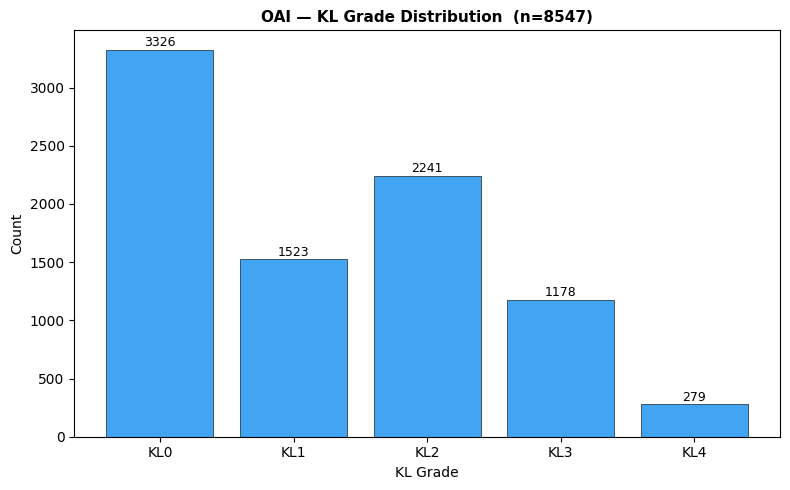

In [11]:

KL_NAMES = ['Normal','Doubtful','Mild','Moderate','Severe']

print('=== S3 KL DISTRIBUTION ===')
lbl_s3    = pd.read_csv(get_oai_labels())
kl_col_s3 = 'kl_grade' if 'kl_grade' in lbl_s3.columns else next(
             (c for c in lbl_s3.columns if 'kl' in c.lower()), None)

s3_issues = []
if kl_col_s3 is None:
    s3_issues.append('No KL column found')
    verdicts['S3'] = 'FAIL'
    print('  [FAIL] No KL column found')
else:
    raw   = pd.to_numeric(lbl_s3[kl_col_s3], errors='coerce')
    n_inv = int(raw.isna().sum()) + int((~raw.isin([0,1,2,3,4]) & raw.notna()).sum())
    kl    = raw[raw.between(0,4)].astype(int)
    vc    = kl.value_counts().sort_index()
    miss  = [k for k in range(5) if vc.get(k,0) == 0]

    if n_inv > 0:   s3_issues.append(f'{n_inv} invalid KL values')
    if miss:        s3_issues.append(f'Missing grades: {miss}')

    print(f'  Valid={len(kl):,}  Invalid={n_inv}  Missing grades={miss}')
    for k in range(5):
        n = int(vc.get(k,0))
        bar = '#' * int(n / max(len(kl),1) * 40)
        print(f'    KL{k} {KL_NAMES[k]:10s}: {n:6,}  ({100*n/max(len(kl),1):.1f}%)  {bar}')

    verdicts['S3'] = 'FAIL' if s3_issues else 'PASS'
    print(f'S3 verdict: {verdicts["S3"]}')
    for m in s3_issues: print(f'  ! {m}')

    vals = [int(vc.get(k,0)) for k in range(5)]
    fig, ax = plt.subplots(figsize=(8, 5))
    bars = ax.bar([f'KL{k}' for k in range(5)], vals,
                  color='#2196F3', alpha=0.85, edgecolor='black', lw=0.5)
    ax.set_xlabel('KL Grade'); ax.set_ylabel('Count')
    ax.set_title('OAI — KL Grade Distribution  (n=' + str(sum(vals)) + ')',
                 fontsize=11, fontweight='bold')
    for bar, n in zip(bars, vals):
        if n > 0:
            ax.text(bar.get_x() + bar.get_width()/2,
                    bar.get_height() + 5, str(n),
                    ha='center', va='bottom', fontsize=9)
    plt.tight_layout()
    plt.savefig(OUT_DIR / 's3_kl_distribution.png',
                dpi=CFG['figure_dpi'], bbox_inches='tight')
    plt.show()
    pd.DataFrame([{'KL': k, 'Name': KL_NAMES[k],
                   'Count': int(vc.get(k,0)),
                   'Pct': round(100*int(vc.get(k,0))/max(len(kl),1), 1)}
                  for k in range(5)]).to_csv(OUT_DIR / 's3_kl_dist.csv', index=False)


---
## S4a — DICOM Tag Audit

In [12]:

print('=== S4a DICOM TAG AUDIT ===')

if not subject_dicoms:
    print('SKIP — no DICOMs available')
    verdicts['S4a'] = 'SKIPPED'
else:
    TAGS   = ['ViewPosition','SeriesDescription','PhotometricInterpretation',
              'PatientPosition','Laterality']
    sids   = [s for s in subject_dicoms if best_dicom(s)]
    sample = random.sample(sids, min(CFG['s4c_dicom_n'], len(sids)))
    tvals  = {t: [] for t in TAGS}
    rows4a = []
    load_errors = 0

    for sid in sample:
        try:
            ds  = pydicom.dcmread(str(best_dicom(sid)), stop_before_pixels=True)
            row = {'subject_id': sid}
            for t in TAGS:
                v = str(getattr(ds, t, 'N/A')).strip()
                row[t] = v; tvals[t].append(v)
            rows4a.append(row)
        except Exception:
            load_errors += 1

    print(f'  Sampled {len(rows4a)} subjects  (load errors: {load_errors})')
    print()
    for t in TAGS:
        print(f'  {t}:')
        for v, n in Counter(tvals[t]).most_common():
            pct = 100 * n / max(len(tvals[t]), 1)
            print(f'    {repr(v):45s}  {n:4d}  ({pct:.0f}%)')
        print()

    sd_vals  = tvals['SeriesDescription']
    sd_pa    = sum(1 for v in sd_vals
                   if 'PA' in str(v).upper() and 'AP' not in str(v).upper())
    sd_ap    = sum(1 for v in sd_vals
                   if 'AP' in str(v).upper() and 'PA' not in str(v).upper())
    sd_pct_pa = 100 * sd_pa / max(len(sd_vals), 1)
    sd_pct_ap = 100 * sd_ap / max(len(sd_vals), 1)

    vp_vals  = tvals['ViewPosition']
    vp_pa    = sum(1 for v in vp_vals
                   if 'PA' in str(v).upper() and 'AP' not in str(v).upper())
    vp_ap    = sum(1 for v in vp_vals
                   if 'AP' in str(v).upper() and 'PA' not in str(v).upper())

    print(f'  SeriesDescription: {sd_pa} PA  {sd_ap} AP  ({sd_pct_pa:.0f}% PA) — PRIMARY')
    print(f'  ViewPosition     : {vp_pa} PA  {vp_ap} AP  (unreliable on OAI, used as secondary)')
    print()

    if   sd_pct_pa >= 95: c4a, reason = 'PASS',    'SeriesDescription unanimous PA (definitive tag)'
    elif sd_pct_ap >= 95: c4a, reason = 'FAIL',    'SeriesDescription unanimous AP — crops REVERSED'
    elif sd_pct_pa >= 70: c4a, reason = 'PASS',    'SeriesDescription majority PA (>=70%)'
    elif sd_pct_ap >= 70: c4a, reason = 'FAIL',    'SeriesDescription majority AP — crops REVERSED'
    else:

        tokens = set()
        for raw in vp_vals + sd_vals:
            u = str(raw).upper()
            if 'PA' in u: tokens.add('PA')
            if 'AP' in u and 'PA' not in u: tokens.add('AP')
        if   tokens == {'PA'}: c4a, reason = 'PASS',    'Combined VP+SD both PA'
        elif tokens == {'AP'}: c4a, reason = 'FAIL',    'Combined VP+SD both AP'
        else:                  c4a, reason = 'UNCLEAR', 'Conflicting tag signals — inspect manually'

    tokens = {'PA'} if 'PASS' in c4a else ({'AP'} if 'FAIL' in c4a else {'PA', 'AP'})

    mono_inv = sum(1 for v in tvals['PhotometricInterpretation']
                   if 'MONOCHROME1' in str(v).upper())

    verdicts['S4a'] = c4a
    print(f'  [{c4a}] {reason}')
    if mono_inv:
        print(f'  NOTE: {mono_inv} MONOCHROME1 files — inversion applied at load time (handled)')
    pd.DataFrame(rows4a).to_csv(OUT_DIR / 's4a_dicom_tags.csv', index=False)
    print(f'S4a verdict: {c4a}')

    _s4a_dicom_cache = {
        'tvals'  : tvals,
        'sample' : sample,
        'n'      : len(rows4a),
        'tokens' : tokens,
    }


=== S4a DICOM TAG AUDIT ===


/usr/local/lib/python3.12/dist-packages/pydicom/charset.py:727: UserWarning: Incorrect value for Specific Character Set 'ISO_2022_IR_6' - assuming 'ISO 2022 IR 6'
  _warn_about_invalid_encoding(encoding, patched)


  Sampled 100 subjects  (load errors: 0)

  ViewPosition:
    'PA'                                             63  (63%)
    ''                                               23  (23%)
    'N/A'                                            11  (11%)
    'AP'                                              3  (3%)

  SeriesDescription:
    'Bilateral PA Fixed Flexion Knee'               100  (100%)

  PhotometricInterpretation:
    'MONOCHROME2'                                    99  (99%)
    'MONOCHROME1'                                     1  (1%)

  PatientPosition:
    'N/A'                                            74  (74%)
    ''                                               26  (26%)

  Laterality:
    ''                                               58  (58%)
    'N/A'                                            25  (25%)
    'L'                                              16  (16%)
    'B'                                               1  (1%)

  SeriesDescription: 100 PA  0 AP  (1

---
## S4b — KL Asymmetry vs Expert JSW Measurements

=== S4b KL ASYMMETRY vs JSW ===
  Subjects with |KL_R - KL_L| >= 2: 786
  Matched to JSW data: 549
  PASS=338  FAIL=102  UNCLEAR=109  (62% pass)
  Note: if S4c orientation is UNCLEAR, FAIL cases here may be mislabelled sides.
S4b verdict: UNCLEAR


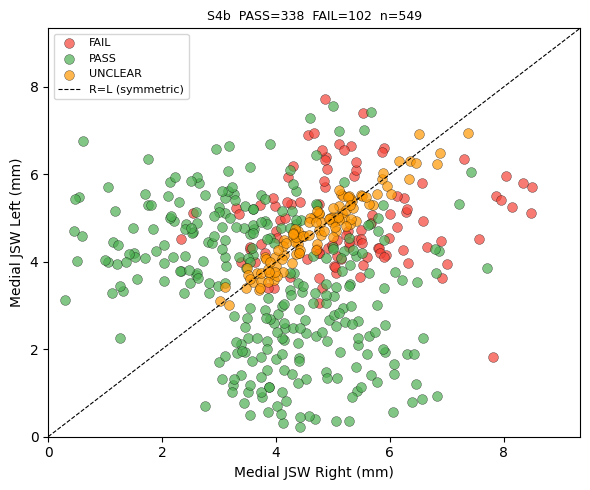

In [13]:

print('=== S4b KL ASYMMETRY vs JSW ===')

if not OAI_LABELS.exists() or not OAI_JSW.exists():
    msg = 'labels' if not OAI_LABELS.exists() else 'JSW file'
    print(f'SKIP — missing: {msg}')
    verdicts['S4b'] = 'SKIPPED'
else:
    lbl  = pd.read_csv(get_oai_labels(), dtype={'subject_id': str})
    lbl['side'] = normalise_side(lbl['side'])
    wide = (lbl.pivot_table(index='subject_id', columns='side',
                            values='kl_grade', aggfunc='first')
            .reset_index())
    wide.columns.name = None
    if not ({'R','L'} <= set(wide.columns)):
        print('SKIP — R/L columns missing after pivot')
        verdicts['S4b'] = 'SKIPPED'
    else:
        wide = wide.rename(columns={'R':'kl_R','L':'kl_L'})
        asym = wide[((wide['kl_R'] - wide['kl_L']).abs() >= 2)].copy()
        print(f'  Subjects with |KL_R - KL_L| >= 2: {len(asym):,}')

        jsw = pd.read_csv(OAI_JSW, sep='|', dtype={'ID': str})
        jsw['ID'] = jsw['ID'].str.strip()
        j_r = jsw[jsw['SIDE']==1][['ID','V00MCMJSW','V00MJSWBB']].rename(
              columns={'V00MCMJSW':'jsw_R','V00MJSWBB':'bb_R'})
        j_l = jsw[jsw['SIDE']==2][['ID','V00MCMJSW','V00MJSWBB']].rename(
              columns={'V00MCMJSW':'jsw_L','V00MJSWBB':'bb_L'})
        jsw_w = j_r.merge(j_l, on='ID')
        for c in ['jsw_R','jsw_L','bb_R','bb_L']:
            jsw_w[c] = pd.to_numeric(jsw_w[c], errors='coerce').fillna(0)

        mg = asym.merge(jsw_w, left_on='subject_id', right_on='ID', how='inner')
        print(f'  Matched to JSW data: {len(mg):,}')

        ok_c = fail_c = unc_c = 0
        rows4b = []
        for _, row in mg.iterrows():
            kr = int(row['kl_R']); kl_v = int(row['kl_L'])
            jr = float(row['jsw_R']); jl = float(row['jsw_L'])
            if jr == 0 and jl == 0:
                res = 'UNCLEAR'
            elif kr > kl_v:
                bb  = bool(row['bb_R'])
                rat = 0.0 if bb else max(jr,1e-3)/max(jl,1e-3)
                res = ('PASS' if bb or rat < CFG['s4b_pass_ratio'] else
                       'FAIL' if rat > CFG['s4b_fail_ratio'] else 'UNCLEAR')
            else:
                bb  = bool(row['bb_L'])
                rat = 0.0 if bb else max(jl,1e-3)/max(jr,1e-3)
                res = ('PASS' if bb or rat < CFG['s4b_pass_ratio'] else
                       'FAIL' if rat > CFG['s4b_fail_ratio'] else 'UNCLEAR')
            if res=='PASS': ok_c += 1
            elif res=='FAIL': fail_c += 1
            else: unc_c += 1
            rows4b.append({'sid': row['subject_id'], 'kl_R': kr, 'kl_L': kl_v,
                           'jsw_R': jr, 'jsw_L': jl, 'result': res})

        total_b = ok_c + fail_c + unc_c
        pct_ok  = 100 * ok_c / max(total_b, 1)
        c4b = ('PASS'    if pct_ok >= CFG['s4b_pass_pct'] else
               'UNCLEAR' if pct_ok >= CFG['s4b_unc_pct']  else 'FAIL')
        verdicts['S4b'] = c4b
        print(f'  PASS={ok_c}  FAIL={fail_c}  UNCLEAR={unc_c}  ({pct_ok:.0f}% pass)')
        print(f'  Note: if S4c orientation is UNCLEAR, FAIL cases here may be mislabelled sides.')
        print(f'S4b verdict: {c4b}')

        df4b = pd.DataFrame(rows4b)
        df4b.to_csv(OUT_DIR / 's4b_kl_asymmetry.csv', index=False)
        df4b_p = df4b[(df4b['jsw_R']>0) & (df4b['jsw_L']>0)]
        if len(df4b_p):
            fig, ax = plt.subplots(figsize=(6, 5))
            clrs = {'PASS':'#4CAF50','FAIL':'#F44336','UNCLEAR':'#FF9800'}
            for res, grp in df4b_p.groupby('result'):
                ax.scatter(grp['jsw_R'], grp['jsw_L'],
                           c=clrs.get(res,'gray'), label=res,
                           alpha=0.7, edgecolors='k', lw=0.3, s=50)
            lim = float(df4b_p[['jsw_R','jsw_L']].max().max()) * 1.1
            ax.plot([0,lim],[0,lim],'k--',lw=0.8,label='R=L (symmetric)')
            ax.set_xlim(0,lim); ax.set_ylim(0,lim)
            ax.set_xlabel('Medial JSW Right (mm)')
            ax.set_ylabel('Medial JSW Left (mm)')
            ax.set_title('S4b  PASS=' + str(ok_c) + '  FAIL=' + str(fail_c) +
                         '  n=' + str(total_b), fontsize=9)
            ax.legend(fontsize=8); plt.tight_layout()
            plt.savefig(OUT_DIR / 's4b_jsw_scatter.png',
                        dpi=CFG['figure_dpi'], bbox_inches='tight')
            plt.show()


---
## S4c — Crop Orientation: Diagnose → Visual Check → Fix → Verify

**The question**: Does image-left correctly map to the patient's right knee?

**Why not the fibula heuristic?** On OAI 224×224 crops, the image-frame border
creates stronger Sobel edge energy than the fibula bone itself. The heuristic
consistently detects borders, not anatomy. It is kept in helpers as a reference
function but plays no role in the verdict.

**What we use instead:**
1. **DICOM `SeriesDescription`** — written by the scanner at acquisition.
   `'Bilateral PA Fixed Flexion Knee'` is unambiguous.
2. **R/L pair visual check** — L should look like a mirror of R.
   This is the definitive human confirmation step.
3. **`orientation_override`** — set to `'PA'` in CFG after visual confirmation.
   Verdict changes from UNCLEAR → PASS only when this is explicitly set.

**Fix**: Only reprocesses if both DICOM and override confirm AP.


In [14]:


print('=== S4c ORIENTATION DIAGNOSIS ===')
print()

if not subject_dicoms:
    print('SKIP — no DICOMs available')
    ORIENTATION   = 'UNKNOWN'
    verdicts['S4c'] = 'SKIPPED'
else:

    if '_s4a_dicom_cache' in dir():
        _dc      = _s4a_dicom_cache
        n_dicom  = _dc['n']
        _tokens  = _dc['tokens']
        _vp_list = _dc['tvals'].get('ViewPosition', [])
        tag_pa   = sum(1 for v in _vp_list
                       if 'PA' in str(v).upper() and 'AP' not in str(v).upper())
        tag_ap   = sum(1 for v in _vp_list
                       if 'AP' in str(v).upper() and 'PA' not in str(v).upper())
        tag_unk  = n_dicom - tag_pa - tag_ap
        if   _tokens == {'PA'}:                       _dsig = 'PA'
        elif _tokens == {'AP'}:                       _dsig = 'AP'
        elif 'PA' in _tokens and 'AP' in _tokens:     _dsig = 'MIXED'
        else:                                         _dsig = None
        src_note = '(reusing S4a scan)'
    else:
        _dsig    = None
        sids_all = [s for s in subject_dicoms if best_dicom(s)]
        n_dicom  = min(CFG['s4c_dicom_n'], len(sids_all))
        sample_dc = random.sample(sids_all, n_dicom)
        tag_pa = tag_ap = tag_unk = 0
        for sid in sample_dc:
            try:
                ds  = pydicom.dcmread(str(best_dicom(sid)), stop_before_pixels=True)
                txt = (str(getattr(ds,'ViewPosition','')) + ' ' +
                       str(getattr(ds,'SeriesDescription',''))).upper()
                if 'AP' in txt and 'PA' not in txt: tag_ap  += 1
                elif 'PA' in txt:                   tag_pa  += 1
                else:                               tag_unk += 1
            except Exception:
                tag_unk += 1
        src_note = '(fresh scan — run S4a first to avoid duplicate DICOM reads)'

    pct_pa = 100 * tag_pa / max(n_dicom, 1)
    pct_ap = 100 * tag_ap / max(n_dicom, 1)

    print('DICOM tag evidence  (n=' + str(n_dicom) + ')  ' + src_note + ':')
    print('  PA : ' + str(tag_pa) + '  (' + str(round(pct_pa)) + '%)')
    print('  AP : ' + str(tag_ap) + '  (' + str(round(pct_ap)) + '%)')
    print('  Unk: ' + str(tag_unk))
    print()

    dicom_signal = (_dsig if _dsig else
                    'PA'  if pct_pa >= 80 else
                    'AP'  if pct_ap >= 80 else 'MIXED')
    print('DICOM signal: ' + dicom_signal)
    print()

    override = CFG.get('orientation_override')
    if override in ('PA', 'AP'):
        ORIENTATION = override
        print('Manual override active: ORIENTATION = ' + ORIENTATION)
    elif dicom_signal == 'PA':
        ORIENTATION = 'PA'
        print('DICOM confirms PA. Run the visual check cell, then set:')
        print("  CFG['orientation_override'] = 'PA'  to lock in PASS.")
    elif dicom_signal == 'AP':
        ORIENTATION = 'AP'
        print('DICOM indicates AP — images need reprocessing.')
    else:
        ORIENTATION = 'NEEDS_MANUAL_CHECK'
        print('Mixed DICOM signals. Run visual check and set override.')

    print()
    print('ORIENTATION = ' + ORIENTATION)

    verdicts['S4c'] = ('PASS'    if ORIENTATION in ('PA','AP') and override is not None else
                       'UNCLEAR' if ORIENTATION == 'PA'                                  else
                       'FAIL'    if ORIENTATION == 'AP' and override is None             else
                       'UNCLEAR')
    print('S4c verdict: ' + verdicts['S4c'])
    if verdicts['S4c'] == 'UNCLEAR':
        print('  -> Confirm visually, then set orientation_override in CFG.')

    pd.DataFrame({'signal': ['DICOM','Override','Final'],
                  'value':  [dicom_signal, str(override), ORIENTATION]}
                ).to_csv(OUT_DIR / 's4c_orientation_signals.csv', index=False)


=== S4c ORIENTATION DIAGNOSIS ===

DICOM tag evidence  (n=100)  (reusing S4a scan):
  PA : 63  (63%)
  AP : 3  (3%)
  Unk: 34

DICOM signal: PA

Manual override active: ORIENTATION = PA

ORIENTATION = PA
S4c verdict: PASS


=== S4c VISUAL CHECK: R/L PAIR COMPARISON ===
For PA: LEFT image should be a rough mirror of RIGHT from same subject.



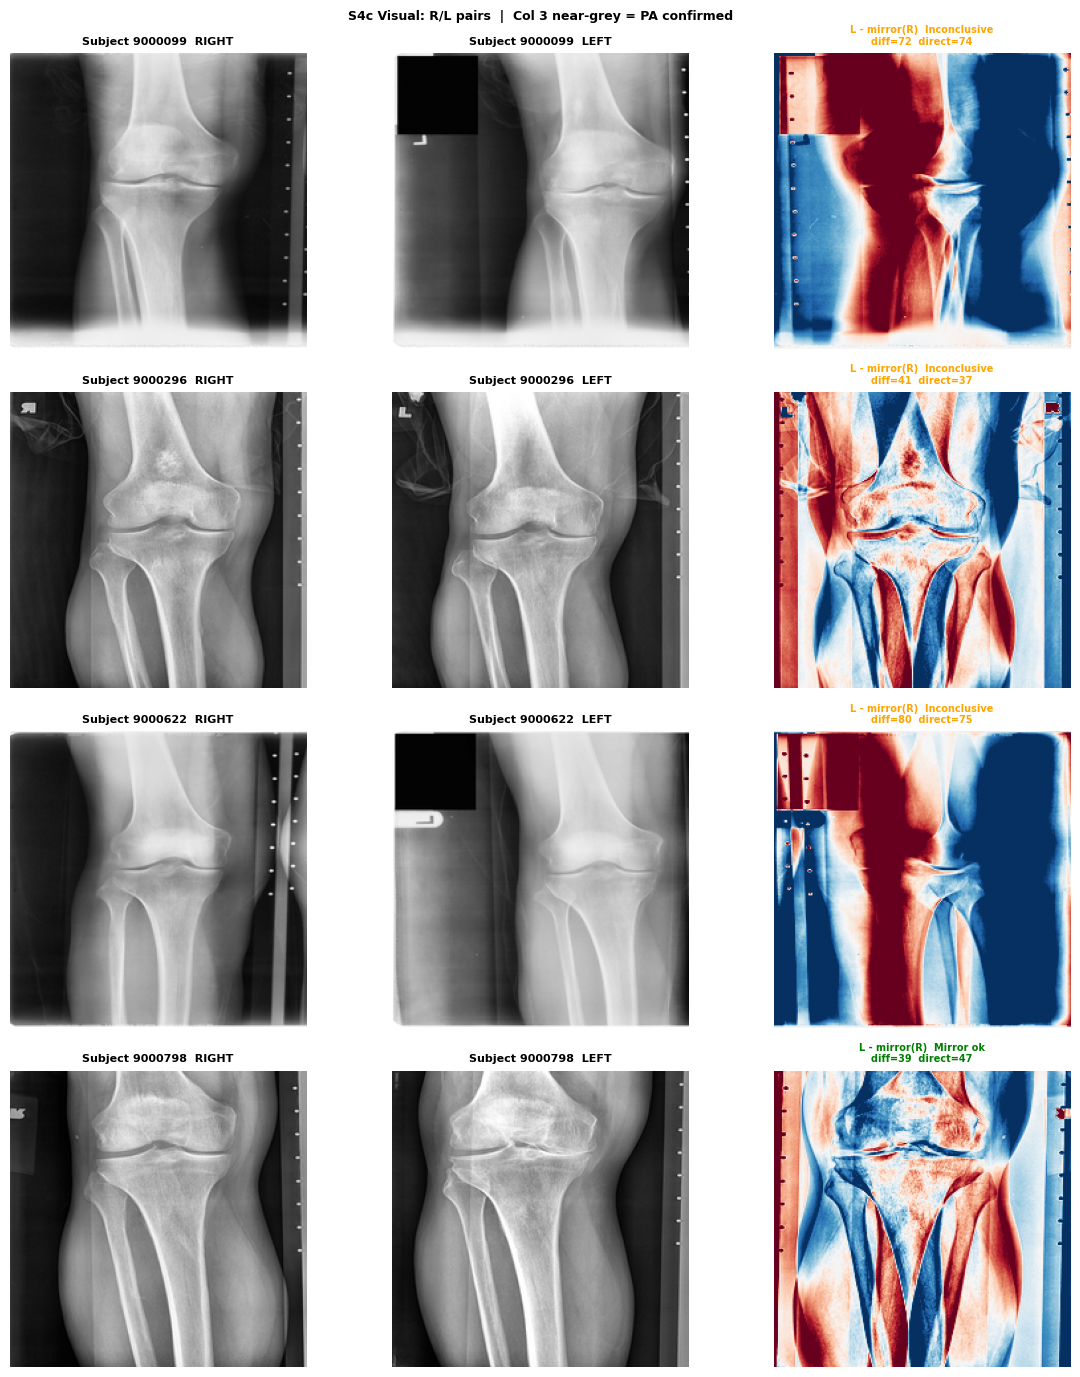

Saved: s4c_rl_pairs.png

ORIENTATION = PA


In [15]:


print('=== S4c VISUAL CHECK: R/L PAIR COMPARISON ===')
print('For PA: LEFT image should be a rough mirror of RIGHT from same subject.')
print()

r_pngs = sorted(list(OAI_PNG_DIR.glob('OAI_*_R_*.png')) or
                list(OAI_PNG_DIR.glob('*_R.png')))

if not r_pngs:
    print('No right-knee PNGs found.')
else:
    pairs = []
    suf   = detect_png_suffix(OAI_PNG_DIR)
    for rp in r_pngs:
        sid, _ = parse_oai_stem(rp.stem)
        if sid is None: continue
        lp = OAI_PNG_DIR / ('OAI_' + sid + '_L' + suf + '.png')
        if lp.exists():
            pairs.append((sid, rp, lp))
        if len(pairs) == 4: break

    if not pairs:
        print('No matching R/L pairs found — check filenames.')
    else:
        fig, axes = plt.subplots(len(pairs), 3, figsize=(12, len(pairs) * 3.5))
        if len(pairs) == 1: axes = [axes]

        for row, (sid, rp, lp) in enumerate(pairs):
            r_arr  = np.array(Image.open(str(rp)).convert('L'))
            l_arr  = np.array(Image.open(str(lp)).convert('L'))
            r_flip = np.fliplr(r_arr)
            d_mirror = float(np.abs(l_arr.astype(float) - r_flip.astype(float)).mean())
            d_direct = float(np.abs(l_arr.astype(float) - r_arr.astype(float)).mean())

            axes[row][0].imshow(r_arr, cmap='gray', vmin=0, vmax=255)
            axes[row][0].set_title('Subject ' + sid + '  RIGHT', fontsize=8, fontweight='bold')
            axes[row][0].axis('off')

            axes[row][1].imshow(l_arr, cmap='gray', vmin=0, vmax=255)
            axes[row][1].set_title('Subject ' + sid + '  LEFT', fontsize=8, fontweight='bold')
            axes[row][1].axis('off')

            diff = l_arr.astype(float) - r_flip.astype(float)
            axes[row][2].imshow(diff, cmap='RdBu', vmin=-80, vmax=80)
            col  = 'green' if d_mirror < d_direct - 3 else 'orange'
            note = 'Mirror ok' if d_mirror < d_direct - 3 else 'Inconclusive'
            axes[row][2].set_title(
                'L - mirror(R)  ' + note + '\ndiff=' + str(round(d_mirror))
                + '  direct=' + str(round(d_direct)),
                fontsize=7, color=col, fontweight='bold')
            axes[row][2].axis('off')

        fig.suptitle('S4c Visual: R/L pairs  |  Col 3 near-grey = PA confirmed',
                     fontsize=9, fontweight='bold')
        plt.tight_layout()
        plt.savefig(OUT_DIR / 's4c_rl_pairs.png', dpi=CFG['figure_dpi'], bbox_inches='tight')
        plt.show()
        print('Saved: s4c_rl_pairs.png')
        print()
        print('ORIENTATION = ' + str(ORIENTATION))
        if CFG.get('orientation_override') is None:
            print()
            print('NEXT STEP:')
            print('  If pairs look mirrored, go to CONFIG cell and set:')
            print("  'orientation_override': 'PA'")
            print('  Then re-run S4c DIAGNOSE.')


In [16]:

assert ORIENTATION is not None, "Run the S4c diagnosis cell first."
print('=== S4c FIX ===')

if ORIENTATION in ('PA', 'UNKNOWN'):
    log('S4c FIX: ORIENTATION=' + ORIENTATION + ' — no reprocessing needed.')

elif ORIENTATION == 'NEEDS_MANUAL_CHECK':
    log('S4c FIX: Orientation ambiguous — no data modified.')
    log("         Set CFG['orientation_override'] = 'PA' or 'AP' and re-run.")

elif ORIENTATION == 'AP':
    log('S4c FIX: AP confirmed — reprocessing all subjects (swap + resize + CLAHE).')
    backup = OAI_PNG_DIR.parent / 'processed_backup'
    if not backup.exists():
        print('Backing up ' + OAI_PNG_DIR.name + ' ...')
        shutil.copytree(str(OAI_PNG_DIR), str(backup))
        print('Backup complete.')
    else:
        print('Backup already exists — skipping.')

    suffix   = detect_png_suffix(OAI_PNG_DIR)
    subjects = pd.read_csv(get_oai_labels(), dtype={'subject_id': str})['subject_id'].unique()
    print('Reprocessing ' + str(len(subjects)) + ' subjects ...')

    def _reprocess_ap(sid):
        dcm = best_dicom(str(sid))
        if dcm is None: return 'no_dicom'
        try:
            full           = load_dicom_uint8(dcm)
            r_raw, l_raw   = split_bilateral(full)
            for side, crop in (('R', l_raw), ('L', r_raw)):
                Image.fromarray(process_crop(crop)).save(
                    str(OAI_PNG_DIR / ('OAI_' + sid + '_' + side + suffix + '.png')))
            return 'ok'
        except Exception:
            return 'error'

    result_list = []
    with ThreadPoolExecutor(max_workers=16) as ex:
        futs = {ex.submit(_reprocess_ap, s): s for s in subjects}
        for i, fut in enumerate(as_completed(futs), 1):
            result_list.append(fut.result())
            if i % 500 == 0 or i == len(subjects):
                print('  ' + str(i) + '/' + str(len(subjects)), end='\r')
    print()
    c = Counter(result_list)
    log('S4c FIX: ok=' + str(c['ok']) + '  no_dicom=' + str(c['no_dicom']) +
        '  errors=' + str(c['error']))


=== S4c FIX ===
S4c FIX: ORIENTATION=PA — no reprocessing needed.


In [17]:

assert ORIENTATION is not None, "Run the S4c diagnosis cell first."
print('=== S4c VERIFY ===')

override = CFG.get('orientation_override')

if ORIENTATION == 'PA' and override == 'PA':
    print('  PA confirmed by DICOM + manual override.')
    verdicts['S4c'] = 'PASS'

elif ORIENTATION == 'PA' and override is None:
    print('  DICOM says PA but manual override not yet set.')
    print("  Set CFG['orientation_override'] = 'PA' and re-run to get PASS.")
    verdicts['S4c'] = 'UNCLEAR'

elif ORIENTATION == 'AP':

    sids_v   = [s for s in subject_dicoms if best_dicom(s)]
    sample_v = random.sample(sids_v, min(30, len(sids_v)))
    pa_v = err_v = 0
    for sid in sample_v:
        try:
            ds  = pydicom.dcmread(str(best_dicom(sid)), stop_before_pixels=True)
            sd  = str(getattr(ds, 'SeriesDescription', '')).upper()
            if 'PA' in sd:
                pa_v += 1
        except Exception:
            err_v += 1
    pct  = 100 * pa_v / max(len(sample_v), 1)
    verdicts['S4c'] = 'PASS' if pct >= 80 else 'UNCLEAR'
    print('  Post-fix DICOM check: ' + str(pa_v) + '/' + str(len(sample_v))
          + ' PA  (' + str(round(pct)) + '%)  load-errors=' + str(err_v)
          + '  [' + verdicts['S4c'] + ']')
    log('S4c VERIFY: ' + str(pa_v) + '/' + str(len(sample_v))
        + ' PA  errors=' + str(err_v) + ' -> ' + verdicts['S4c'])

else:
    verdicts['S4c'] = 'UNCLEAR'
    print('  Orientation = ' + ORIENTATION + ' — resolve before training.')

print('S4c verdict: ' + verdicts['S4c'])


=== S4c VERIFY ===
  PA confirmed by DICOM + manual override.
S4c verdict: PASS


---
## S4d — Label Cross-Validation + QWK

=== S4d LABEL CROSS-VALIDATION ===
  SQ rows: 16,666   columns (first 8): ['ID', 'SIDE', 'READPRJ', 'VERSION', 'V00BARCDBU', 'V00XROSFM', 'V00XRSCFM', 'V00XRCYFM']

  Raw column samples (first 5 non-null values each):
    ID        : ['9000099', '9000099', '9000296', '9000296', '9000622']   (null=0 of 16,666)
    SIDE      : ['1: Right', '2: Left', '1: Right', '2: Left', '1: Right']   (null=0 of 16,666)
    V00XRKL   : ['2: 2', '3: 3', '2: 2', '3: 3', '1: 1']   (null=0 of 16,666)
    SIDE unique (raw): ['1: Right', '2: Left']
    side mapped      : {'L': 8359, 'R': 8307}
    V00XRKL parsed   : {0.0: 8085, 1.0: 3575, 2.0: 3152, 3.0: 1466, 4.0: 314}
    V00XRKL nulls    : 74

  NaN counts before dropna:
    ID          : 0 NaN  (0%)
    side        : 0 NaN  (0%)
    kl_official : 74 NaN  (0%)
  Rows after dropna: 16,592

  Join diagnostics:
    Labels  subject_id sample : ['9000099', '9000296', '9000622', '9000798', '9001104']
    SQ file ID         sample : ['9000099', '9000296', '90006

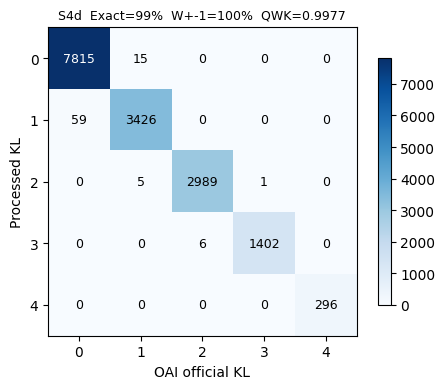

In [28]:

print('=== S4d LABEL CROSS-VALIDATION ===')

if not Path(get_oai_labels()).exists() or not OAI_SQ.exists():
    msg = 'labels' if not Path(get_oai_labels()).exists() else 'SQ assessment file'
    print(f'SKIP — missing: {msg}')
    verdicts['S4d'] = 'SKIPPED'
else:

    try:
        sq = pd.read_csv(OAI_SQ, sep='|', dtype={'ID': str},
                         na_values='.', on_bad_lines='skip')
    except Exception as e:
        print(f'  ERROR loading SQ file: {e}')
        verdicts['S4d'] = 'SKIPPED'
        sq = None

    if sq is not None:
        sq.columns = sq.columns.str.strip().str.upper()
        print(f'  SQ rows: {len(sq):,}   columns (first 8): {list(sq.columns[:8])}')

        required = {'ID', 'SIDE', 'V00XRKL'}
        missing_cols = required - set(sq.columns)
        if missing_cols:
            print(f'  ERROR: columns missing: {missing_cols}')
            print(f'  All columns: {list(sq.columns)}')
            verdicts['S4d'] = 'SKIPPED'
            sq = None

    if sq is not None:

        print()
        print('  Raw column samples (first 5 non-null values each):')
        for col in ['ID', 'SIDE', 'V00XRKL']:
            sample = sq[col].dropna().head(5).tolist()
            n_null = int(sq[col].isna().sum())
            print(f'    {col:10s}: {sample}   (null={n_null:,} of {len(sq):,})')

        sq['ID'] = sq['ID'].astype(str).str.strip().replace('nan', pd.NA)

        side_raw = sq['SIDE'].astype(str).str.strip().str.upper()
        side_key = side_raw.str.extract(r'^([12RL])')[0]
        sq['side'] = side_key.map({'1': 'R', '2': 'L', 'R': 'R', 'L': 'L'})
        print(f'    SIDE unique (raw): {sq["SIDE"].astype(str).str.strip().unique()[:8].tolist()}')
        print(f'    side mapped      : {sq["side"].value_counts().to_dict()}')

        sq['kl_official'] = pd.to_numeric(
            sq['V00XRKL'].astype(str).str.extract(r'(\d+)')[0], errors='coerce')
        kl_nulls = int(sq['kl_official'].isna().sum())
        print(f'    V00XRKL parsed   : {sq["kl_official"].value_counts().sort_index().to_dict()}')
        print(f'    V00XRKL nulls    : {kl_nulls:,}')

        print()
        print('  NaN counts before dropna:')
        for col in ['ID', 'side', 'kl_official']:
            n = int(sq[col].isna().sum())
            print(f'    {col:12s}: {n:,} NaN  ({100*n/max(len(sq),1):.0f}%)')

        sq_c = sq[['ID', 'side', 'kl_official']].dropna()
        print(f'  Rows after dropna: {len(sq_c):,}')

        lbl = pd.read_csv(get_oai_labels(), dtype={'subject_id': str})
        lbl['subject_id'] = lbl['subject_id'].astype(str).str.strip()
        lbl['side'] = normalise_side(lbl['side'])

        print()
        print('  Join diagnostics:')
        lbl_ids = set(lbl['subject_id'].unique())
        sq_ids  = set(sq_c['ID'].unique())
        overlap = lbl_ids & sq_ids
        print(f'    Labels  subject_id sample : {sorted(lbl_ids)[:5]}')
        print(f'    SQ file ID         sample : {sorted(sq_ids)[:5]}')
        print(f'    Labels  total subjects    : {len(lbl_ids):,}')
        print(f'    SQ file total subjects    : {len(sq_ids):,}')
        print(f'    Direct ID overlap         : {len(overlap):,}')

        join_lbl = lbl.copy()
        join_sq  = sq_c.copy()

        if not overlap:
            join_lbl['subject_id'] = join_lbl['subject_id'].str.zfill(7)
            join_sq['ID']          = join_sq['ID'].str.zfill(7)
            ov1 = set(join_lbl['subject_id']) & set(join_sq['ID'])
            print(f'    After zero-pad to 7      : {len(ov1):,} overlap')

            if not ov1:
                join_lbl['subject_id'] = join_lbl['subject_id'].str.lstrip('0')
                join_sq['ID']          = join_sq['ID'].str.lstrip('0')
                ov2 = set(join_lbl['subject_id']) & set(join_sq['ID'])
                print(f'    After strip leading zeros: {len(ov2):,} overlap')

                if not ov2:
                    try:
                        join_lbl['subject_id'] = pd.to_numeric(
                            join_lbl['subject_id'], errors='coerce'
                        ).astype('Int64').astype(str)
                        join_sq['ID'] = pd.to_numeric(
                            join_sq['ID'], errors='coerce'
                        ).astype('Int64').astype(str)
                        ov3 = set(join_lbl['subject_id']) & set(join_sq['ID'])
                        print(f'    After numeric cast       : {len(ov3):,} overlap')
                    except Exception:
                        ov3 = set()
                    if not ov3:
                        print()
                        print('  WARNING: No ID overlap after all attempts.')
                        print('  Paste the raw column samples above into the chat.')
        print()

        mg = join_lbl.merge(join_sq, left_on=['subject_id', 'side'],
                            right_on=['ID', 'side'])
        mg['kl_grade']    = pd.to_numeric(mg['kl_grade'],    errors='coerce')
        mg['kl_official'] = pd.to_numeric(mg['kl_official'], errors='coerce')
        mg = mg.dropna(subset=['kl_grade', 'kl_official'])
        mg = mg[mg['kl_grade'].between(0, 4) & mg['kl_official'].between(0, 4)]
        mg['diff'] = (mg['kl_grade'] - mg['kl_official']).abs()

        total   = len(mg)
        exact   = int((mg['diff'] == 0).sum())
        within1 = int((mg['diff'] <= 1).sum())
        kappa   = quadratic_weighted_kappa(mg['kl_official'].values, mg['kl_grade'].values)
        pct_e   = 100 * exact   / max(total, 1)
        pct_w1  = 100 * within1 / max(total, 1)
        k_str   = f'{kappa:.4f}' if pd.notna(kappa) else 'N/A'

        print(f'  Matched records  : {total:,}')
        print(f'  Exact match      : {exact:>6,}  ({pct_e:.1f}%)')
        print(f'  Within +/-1 grade: {within1:>6,}  ({pct_w1:.1f}%)')
        print(f'  QWK kappa        : {k_str}')

        c4d = ('PASS'    if pct_w1 >= CFG['s4d_w1_pass_pct'] else
               'UNCLEAR' if pct_w1 >= CFG['s4d_w1_unc_pct']  else 'FAIL')
        verdicts['S4d'] = c4d
        print(f'S4d verdict: {c4d}')

        mg[['subject_id', 'side', 'kl_grade', 'kl_official', 'diff']].to_csv(
            OUT_DIR / 's4d_label_xval.csv', index=False)

        if total > 0:
            conf = (pd.crosstab(mg['kl_grade'].astype(int), mg['kl_official'].astype(int))
                    .reindex(index=range(5), columns=range(5), fill_value=0).values)
            fig, ax = plt.subplots(figsize=(5, 4))
            im = ax.imshow(conf, cmap='Blues')
            ax.set_xticks(range(5)); ax.set_yticks(range(5))
            ax.set_xlabel('OAI official KL')
            ax.set_ylabel('Processed KL')
            ax.set_title('S4d  Exact=' + str(round(pct_e)) + '%  W+-1=' +
                         str(round(pct_w1)) + '%  QWK=' + k_str, fontsize=9)
            for i in range(5):
                for j in range(5):
                    ax.text(j, i, str(conf[i, j]), ha='center', va='center',
                            fontsize=9,
                            color='white' if conf[i, j] > conf.max() * 0.6 else 'black')
            plt.colorbar(im, ax=ax, shrink=0.8)
            plt.tight_layout()
            plt.savefig(OUT_DIR / 's4d_confusion.png',
                        dpi=CFG['figure_dpi'], bbox_inches='tight')
            plt.show()
        else:
            verdicts['S4d'] = 'FAIL'
            print('  No matched records — confusion matrix skipped.')

---
## S4e — R/L Side Balance

=== S4e R/L SIDE BALANCE ===
side         R     L  total  pct_R  pct_L  abs_gap
kl_grade                                          
0         1617  1709   3326   48.6   51.4      2.8
1          763   760   1523   50.1   49.9      0.2
2         1160  1081   2241   51.8   48.2      3.5
3          584   594   1178   49.6   50.4      0.8
4          143   136    279   51.3   48.7      2.5

Max R/L gap: 3.5 percentage points
Grades with one side entirely missing: 0
S4e verdict: PASS


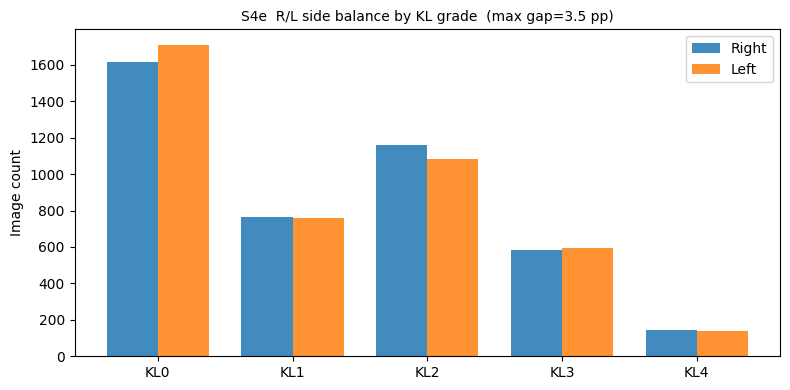

In [19]:

print('=== S4e R/L SIDE BALANCE ===')

lbl_e = pd.read_csv(get_oai_labels(), dtype={'subject_id': str})
lbl_e['side']     = normalise_side(lbl_e['side'])
lbl_e             = lbl_e[lbl_e['side'].isin(['R','L'])]
lbl_e['kl_grade'] = pd.to_numeric(lbl_e['kl_grade'], errors='coerce')
lbl_e             = lbl_e.dropna(subset=['kl_grade'])

counts = (lbl_e.groupby(['kl_grade','side']).size()
          .unstack('side', fill_value=0)
          .reindex(index=range(5), fill_value=0)
          .reindex(columns=['R','L'], fill_value=0))
counts['total']   = counts['R'] + counts['L']
counts['pct_R']   = np.where(counts['total']>0,
                              counts['R']/counts['total']*100, 0.0)
counts['pct_L']   = 100 - counts['pct_R']
counts['abs_gap'] = (counts['pct_R'] - counts['pct_L']).abs()

max_gap  = float(counts['abs_gap'].max())
sev_miss = int(((counts[['R','L']].min(axis=1)==0) & (counts['total']>0)).sum())

print(counts[['R','L','total','pct_R','pct_L','abs_gap']].round(1).to_string())
print()
print(f'Max R/L gap: {max_gap:.1f} percentage points')
print(f'Grades with one side entirely missing: {sev_miss}')

c4e = ('FAIL'    if sev_miss>0 or max_gap>CFG['s4e_fail_gap'] else
       'UNCLEAR' if max_gap>CFG['s4e_unc_gap']                  else 'PASS')
verdicts['S4e'] = c4e
print(f'S4e verdict: {c4e}')
counts.reset_index().to_csv(OUT_DIR / 's4e_side_balance.csv', index=False)

fig, ax = plt.subplots(figsize=(8, 4))
x = np.arange(5); w = 0.38
ax.bar(x-w/2, counts['R'].values, w, label='Right', color='#1f77b4', alpha=0.85)
ax.bar(x+w/2, counts['L'].values, w, label='Left',  color='#ff7f0e', alpha=0.85)
ax.set_xticks(x); ax.set_xticklabels([f'KL{k}' for k in range(5)])
ax.set_ylabel('Image count'); ax.legend()
ax.set_title('S4e  R/L side balance by KL grade  (max gap=' + str(round(max_gap,1)) + ' pp)',
             fontsize=10)
plt.tight_layout()
plt.savefig(OUT_DIR / 's4e_side_balance.png',
            dpi=CFG['figure_dpi'], bbox_inches='tight')
plt.show()


---
## S4f — Train/Val/Test Split: Check → Fix → Verify

In [20]:

print('=== S4f SPLIT CHECK ===')
df_sp = pd.read_csv(get_oai_labels(), dtype={'subject_id': str})
if 'split' in df_sp.columns:
    vc = df_sp['split'].value_counts()
    print(f"  Split column present: " +
          '  '.join(f'{s}={vc.get(s,0):,}' for s in ['train','val','test']))
else:
    print('  No split column — will be created in the fix cell.')


=== S4f SPLIT CHECK ===
  Split column present: train=5,983  val=1,284  test=1,280


In [21]:

print('=== S4f FIX ===')
df_sp = pd.read_csv(get_oai_labels(), dtype={'subject_id': str})
if 'split' in df_sp.columns:
    log('S4f FIX: split column already present — skipped')
else:
    id_col = 'subject_id' if 'subject_id' in df_sp.columns else df_sp.columns[0]
    df_sp  = stratified_subject_split(df_sp, subject_col=id_col,
                                       seed=CFG['split_seed'])
    atomic_save_csv(df_sp, get_oai_labels())
    vc = df_sp['split'].value_counts()
    log('S4f FIX: created — ' +
        '  '.join(f'{s}={vc.get(s,0):,}' for s in ['train','val','test']))


=== S4f FIX ===
S4f FIX: split column already present — skipped


In [22]:

print('=== S4f SPLIT VERIFY ===')
df_sp = pd.read_csv(get_oai_labels(), dtype={'subject_id': str})
id_col = 'subject_id' if 'subject_id' in df_sp.columns else df_sp.columns[0]

if 'split' not in df_sp.columns:
    verdicts['S4f'] = 'FAIL'
    print('  [FAIL] split column still missing')
else:
    issues = []
    df_sp['split']    = df_sp['split'].astype(str).str.strip().str.lower()
    df_sp['kl_grade'] = pd.to_numeric(df_sp.get('kl_grade',
                                       pd.Series(dtype=float)), errors='coerce')

    leaked = df_sp.groupby(id_col)['split'].nunique()
    if (leaked > 1).any():
        issues.append(f'{(leaked>1).sum()} subjects appear in more than one split — DATA LEAKAGE')

    if 'side' in df_sp.columns:
        dups = df_sp.duplicated(subset=[id_col,'side'], keep=False).sum()
        if dups: issues.append(f'{dups} duplicate subject-side rows')

    kl_tbl = (df_sp.dropna(subset=['kl_grade'])
               .assign(kl_int=lambda d: d['kl_grade'].astype(int))
               .pivot_table(index='split', columns='kl_int',
                            values=id_col, aggfunc='count', fill_value=0)
               .reindex(index=['train','val','test'], fill_value=0)
               .reindex(columns=range(5), fill_value=0))
    try:
        _, pval, _, _ = chi2_contingency(kl_tbl.values)
        if pval < CFG['split_kl_pval']:
            issues.append(f'KL distribution skewed across splits (chi2 p={pval:.4g})')
        print(f'  Chi-squared p={pval:.4f}  (want > {CFG["split_kl_pval"]})')
    except Exception as e:
        print(f'  Chi-squared unavailable: {e}')

    print()
    print('  Split x KL grade:')
    print(kl_tbl.to_string())

    vc = df_sp['split'].value_counts()
    print()
    print('  Counts: ' + '  '.join(f'{s}={vc.get(s,0):,}' for s in ['train','val','test']))

    verdicts['S4f'] = 'FAIL' if issues else 'PASS'
    print()
    print(f'  [{"FAIL" if issues else "PASS"}] OAI split' +
          (f'  Issues: {issues}' if issues else ''))
    print(f'S4f verdict: {verdicts["S4f"]}')
    kl_tbl.to_csv(OUT_DIR / 's4f_split_kl.csv')


=== S4f SPLIT VERIFY ===
  Chi-squared p=0.9901  (want > 0.05)

  Split x KL grade:
kl_int     0     1     2    3    4
split                             
train   2332  1047  1582  826  196
val      500   238   330  174   42
test     494   238   329  178   41

  Counts: train=5,983  val=1,284  test=1,280

  [PASS] OAI split
S4f verdict: PASS


---
## S7 — Sample Image Grid

=== S7 SAMPLE GRID ===


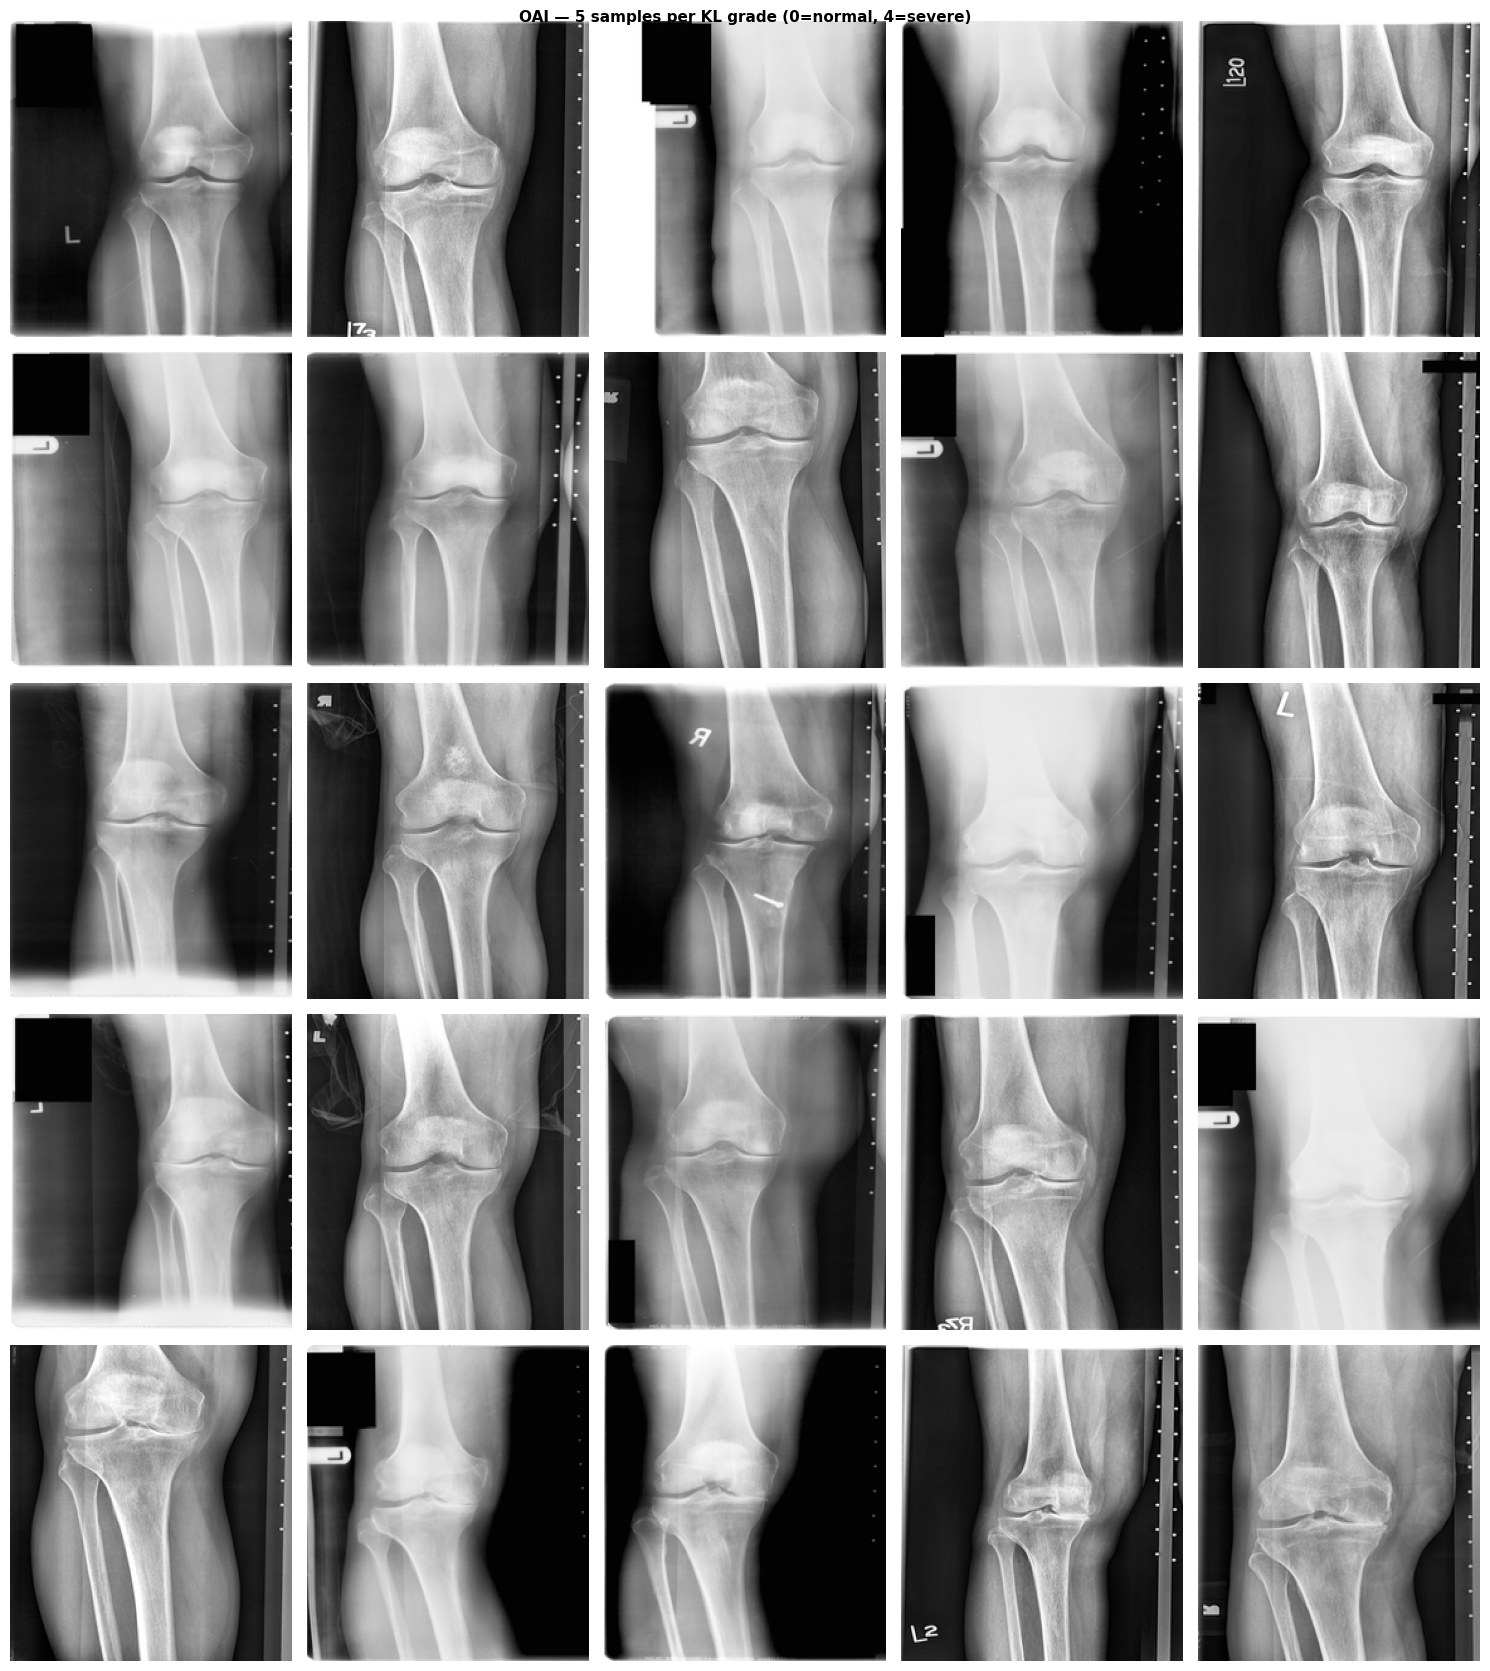

Saved: s7_samples_oai.png


In [23]:

print('=== S7 SAMPLE GRID ===')
lbl_s7 = pd.read_csv(get_oai_labels())
kl_col_s7 = 'kl_grade' if 'kl_grade' in lbl_s7.columns else None
fn_col_s7  = 'filename' if 'filename' in lbl_s7.columns else lbl_s7.columns[0]

if kl_col_s7 is None:
    print('SKIP — no KL column')
else:
    all_pngs = {p.stem: p for p in OAI_PNG_DIR.glob('*.png')}                if OAI_PNG_DIR.exists() else {}

    def resolve(fn):
        p = Path(str(fn))
        for cand in [p, OAI_PNG_DIR/p.name, OAI_PNG_DIR/(p.stem+'.png')]:
            if cand.exists(): return cand
        return all_pngs.get(p.stem)

    N_PER_KL = 5
    KL_LABELS = ['Normal','Doubtful','Mild','Moderate','Severe']
    fig, axes = plt.subplots(5, N_PER_KL, figsize=(N_PER_KL*3, 17))
    for kl in range(5):
        sub = lbl_s7[lbl_s7[kl_col_s7]==kl].reset_index(drop=True)
        for j in range(N_PER_KL):
            ax = axes[kl][j]
            if j < len(sub):
                p = resolve(sub.iloc[j][fn_col_s7])
                if p:
                    arr = np.array(Image.open(str(p)))
                    ax.imshow(arr, cmap='gray' if arr.ndim==2 else None,
                              aspect='auto', vmin=0, vmax=255)
                else:
                    ax.text(.5,.5,'missing',ha='center',va='center',
                            fontsize=8,color='red',transform=ax.transAxes)
            else:
                ax.text(.5,.5,'n/a',ha='center',va='center',
                        fontsize=8,color='gray',transform=ax.transAxes)
            if j == 0:
                ax.set_ylabel('KL' + str(kl) + '\n' + KL_LABELS[kl],
                              fontsize=9, rotation=0, ha='right', va='center',
                              labelpad=55)
            ax.axis('off')
    fig.suptitle('OAI — 5 samples per KL grade (0=normal, 4=severe)',
                 fontsize=11, fontweight='bold')
    plt.tight_layout()
    out_s7 = OUT_DIR / 's7_samples_oai.png'
    plt.savefig(str(out_s7), dpi=CFG['figure_dpi'], bbox_inches='tight')
    plt.show()
    print(f'Saved: {out_s7.name}')


---
## S8 — Final Report

In [29]:

CHECKS = [
    ('S1',  'File inventory        — PNG <-> label match >= 98%'),
    ('S2',  'Image integrity       — 224x224, grayscale, brightness'),
    ('S3',  'KL distribution       — valid grades 0-4, all 5 present'),
    ('S4a', 'DICOM tags            — PA view confirmed in metadata'),
    ('S4b', 'KL asymmetry          — agrees with expert JSW measurements'),
    ('S4c', 'Crop orientation      — fibula + DICOM + visual check'),
    ('S4d', 'Label cross-val       — agrees with official OAI grades (QWK)'),
    ('S4e', 'R/L side balance      — R and L counts similar per KL grade'),
    ('S4f', 'Train/val/test split  — stratified, no leakage, chi2 verified'),
]
SYM = {'PASS':'PASS   ','FAIL':'FAIL   ','UNCLEAR':'UNCLEAR',
       'SKIPPED':'SKIP   ','?':'?      '}

print('=' * 72)
print('  OAI PIPELINE REPORT  —  Grade  Fix  Verify')
print('=' * 72)
for cid, desc in CHECKS:
    v = verdicts.get(cid, '?')
    print(f'  [{SYM.get(v,v):7s}]  {cid:4s}  {desc}')

print()
fails   = [c for c, _ in CHECKS if verdicts.get(c) == 'FAIL']
unclear = [c for c, _ in CHECKS if verdicts.get(c) in ('UNCLEAR',)]

if not fails:
    overall = 'PASS'
    print('  OVERALL: PASS — OAI dataset is ready for model training.')
    if unclear:
        print(f'           {len(unclear)} check(s) need manual review: {unclear}')
        if 'S4c' in unclear:
            print()
            print('  S4c ACTION: Inspect s4c_orientation_spotcheck.png, then:')
            print("             Set CFG['orientation_override'] = 'PA' or 'AP'")
            print('             Re-run S4c cells to confirm.')
else:
    overall = 'FAIL'
    print(f'  OVERALL: FAIL — {len(fails)} blocking issue(s): {fails}')
    print('           Resolve these before training.')
    if 'S4c' in fails:
        print()
        print('  S4c ACTION: All images have been reprocessed with AP-swap.')
        print('             Re-run the full notebook to verify the fix worked.')

print()
print('-' * 72)
print('Changes made this run:')
if fix_log:
    for entry in fix_log: print(f'  > {entry}')
else:
    print('  No changes made.')

ts = pd.Timestamp.now(tz='UTC').isoformat()
print()
print(f'  Timestamp : {ts}')
print(f'  Output dir: {OUT_DIR}')

pd.DataFrame(
    [(c, verdicts.get(c,'?'), d) for c, d in CHECKS],
    columns=['check','verdict','description']
).to_csv(OUT_DIR / 'pipeline_summary.csv', index=False)
pd.DataFrame({'fix': fix_log}).to_csv(OUT_DIR / 'fix_log.csv', index=False)
pd.DataFrame([{'overall': overall, 'timestamp': ts,
               'oai_pngs': len(list(OAI_PNG_DIR.glob('*.png')))
                           if OAI_PNG_DIR.exists() else -1}]
             ).to_csv(OUT_DIR / 'run_metadata.csv', index=False)
print('Saved: pipeline_summary.csv  fix_log.csv  run_metadata.csv')


  OAI PIPELINE REPORT  —  Grade  Fix  Verify
  [PASS   ]  S1    File inventory        — PNG <-> label match >= 98%
  [PASS   ]  S2    Image integrity       — 224x224, grayscale, brightness
  [PASS   ]  S3    KL distribution       — valid grades 0-4, all 5 present
  [PASS   ]  S4a   DICOM tags            — PA view confirmed in metadata
  [UNCLEAR]  S4b   KL asymmetry          — agrees with expert JSW measurements
  [PASS   ]  S4c   Crop orientation      — fibula + DICOM + visual check
  [PASS   ]  S4d   Label cross-val       — agrees with official OAI grades (QWK)
  [PASS   ]  S4e   R/L side balance      — R and L counts similar per KL grade
  [PASS   ]  S4f   Train/val/test split  — stratified, no leakage, chi2 verified

  OVERALL: PASS — OAI dataset is ready for model training.
           1 check(s) need manual review: ['S4b']

------------------------------------------------------------------------
Changes made this run:
  > S1 FIX: no stray PNGs
  > S1 FIX: no missing PNGs
  > S2 FI